In [8]:
# Import libraries               # Same
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Reload the original dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Convert date column
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# Convert skill strings into real Python lists
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

# Now filter to Data Analyst jobs
df = df[df['job_title_short'] == 'Data Analyst']


<Axes: xlabel='skill_count', ylabel='skill_pay'>

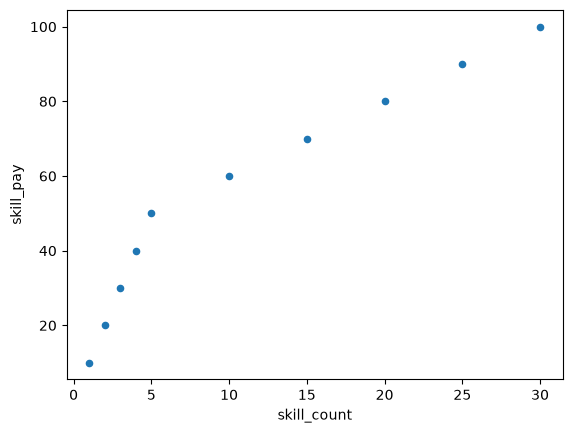

In [5]:
# Create sample data for the scatter plot
data = {
    'job_skills': ['python', 'sql', 'java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
    'skill_count': [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],      # X-axis: number of job postings
    'skill_pay': [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]   # Y-axis: average salary (example)
}

# Convert the dictionary into a DataFrame
df = pd.DataFrame(data)

# Create a scatter plot
df.plot(
    kind='scatter',        # Scatter plot (one dot per row)
    x='skill_count',       # X-axis: demand for the skill
    y='skill_pay'          # Y-axis: salary for the skill
)

In [9]:
# Split each list of skills into separate rows
# explode() turns ['python', 'sql'] into two separate rows:
# python
# sql
df_exploded = df.explode('job_skills')

# Group by each skill and calculate summary statistics
skill_stats = df_exploded.groupby('job_skills').agg(

    # Count how many job postings mention each skill
    skill_count=('job_skills', 'count'),

    # Calculate the median salary for jobs requiring each skill
    median_salary=('salary_year_avg', 'median')
)

# Sort skills by demand (highest count first)
skill_stats.sort_values(by='skill_count')

,skill_count,median_salary
job_skills,,
msaccess,1,NaN
suse,1,NaN
chainer,1,100000.0
ovh,1,NaN
capacitor,1,NaN
...,...,...
power bi,39380,90000.0
tableau,46455,95000.0
python,57190,98500.0


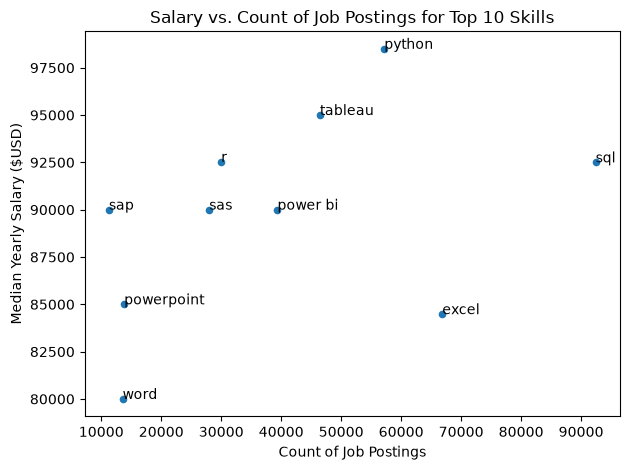

In [12]:
# Create the scatter plot
skill_stats.plot(
    kind='scatter',
    x='skill_count',
    y='median_salary'
)

# Add labels and title
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 10 Skills')
plt.tight_layout()

# Loop through every skill so we can label each point
for i, txt in enumerate(skill_stats.index):
    plt.text(
        skill_stats['skill_count'].iloc[i],      # X-coordinate of the point
        skill_stats['median_salary'].iloc[i],    # Y-coordinate of the point
        txt                                      # Text label (skill name)
    )

plt.show()